### Data loading, Shape Inspection, Null value check, Type conversion

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

In [2]:
df=pd.read_csv("C:\\Users\\lenovo\\Downloads\\Unemployment in India.csv")

In [3]:
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
189,Maharashtra,2019-05-31,Monthly,3.67,23896858.0,47.11,Rural
740,West Bengal,2019-05-31,Monthly,7.25,11306177.0,46.37,Urban
519,Jharkhand,2019-05-31,Monthly,17.23,2404033.0,43.25,Urban
40,Chhattisgarh,2019-05-31,Monthly,9.82,6259019.0,42.89,Rural


In [30]:
df.shape

(768, 7)

In [47]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [48]:
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [49]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [50]:
df.columns =df.columns.str.strip()

In [11]:
# Convert numerical columns to numeric type

In [51]:
df["Estimated Unemployment Rate (%)"] = pd.to_numeric(df["Estimated Unemployment Rate (%)"],errors="coerce")

In [52]:
df["Estimated Labour Participation Rate (%)"] = pd.to_numeric(df["Estimated Labour Participation Rate (%)"],errors="coerce")

In [53]:
df["Estimated Employed"] = pd.to_numeric(df["Estimated Employed"],errors="coerce")

In [54]:
df.dtypes

Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object

### EDA: Region-wise average unemployment rates, month-wise trends

In [28]:
# Region-wise average unemployment rates

In [55]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)
region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Andhra Pradesh       9.632544
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

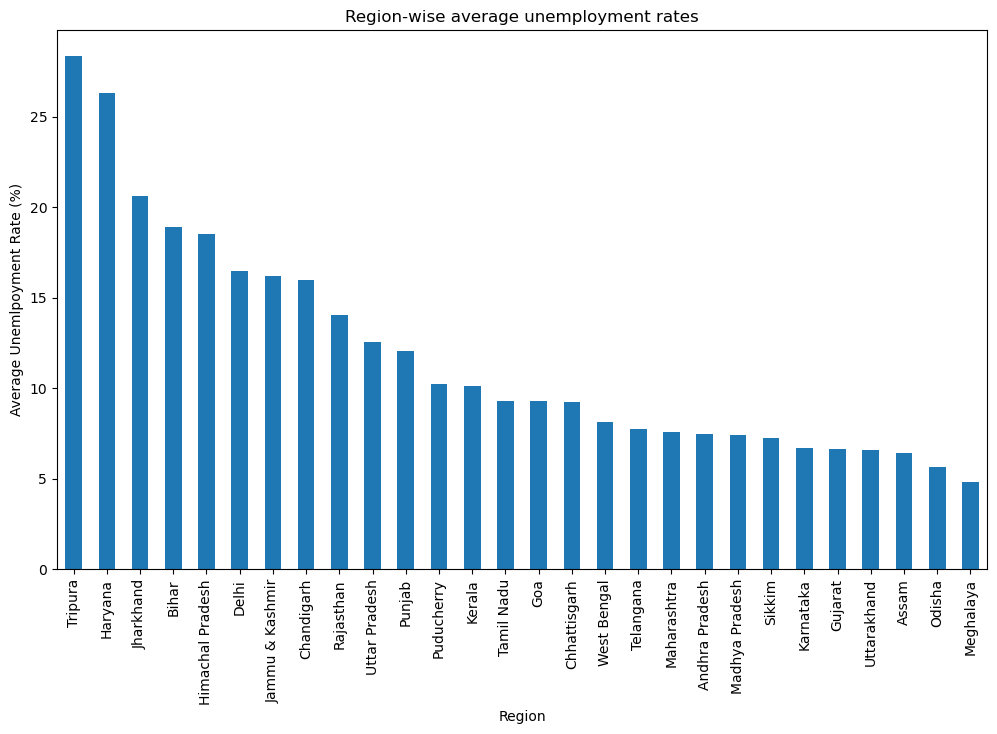

In [31]:
plt.figure(figsize=(12, 7))
region_avg.plot(kind="bar")

plt.title("Region-wise average unemployment rates")
plt.xlabel("Region")
plt.ylabel("Average Unemlpoyment Rate (%)")

plt.xticks(rotation=90)
plt.show()

In [33]:
# Month-wise average unemployment rate


In [57]:
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

In [58]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [59]:
df = df.sort_values('Date')

In [64]:
monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()
monthly_avg

Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30    10.515934
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64

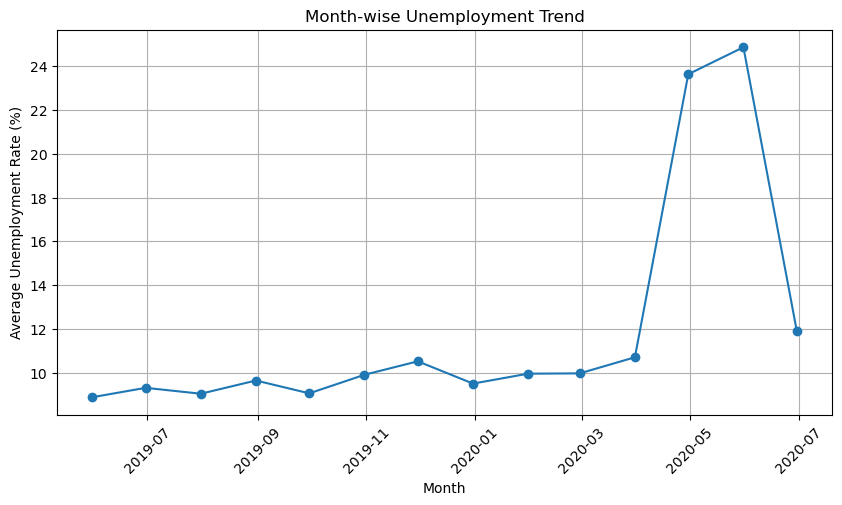

In [63]:
plt.figure(figsize=(10,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')

plt.title("Month-wise Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# 

In [65]:
df.columns = df.columns.str.strip()

In [68]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Date']

0     2019-05-31
189   2019-05-31
740   2019-05-31
519   2019-05-31
40    2019-05-31
         ...    
39    2020-06-30
132   2020-06-30
629   2020-06-30
256   2020-06-30
588   2020-06-30
Name: Date, Length: 768, dtype: datetime64[ns]

In [70]:
states = ['Maharashtra', 'Uttar Pradesh', 'West Bengal']


['Maharashtra', 'Uttar Pradesh', 'West Bengal']

In [71]:
data = df[df['Region'].isin(states)]

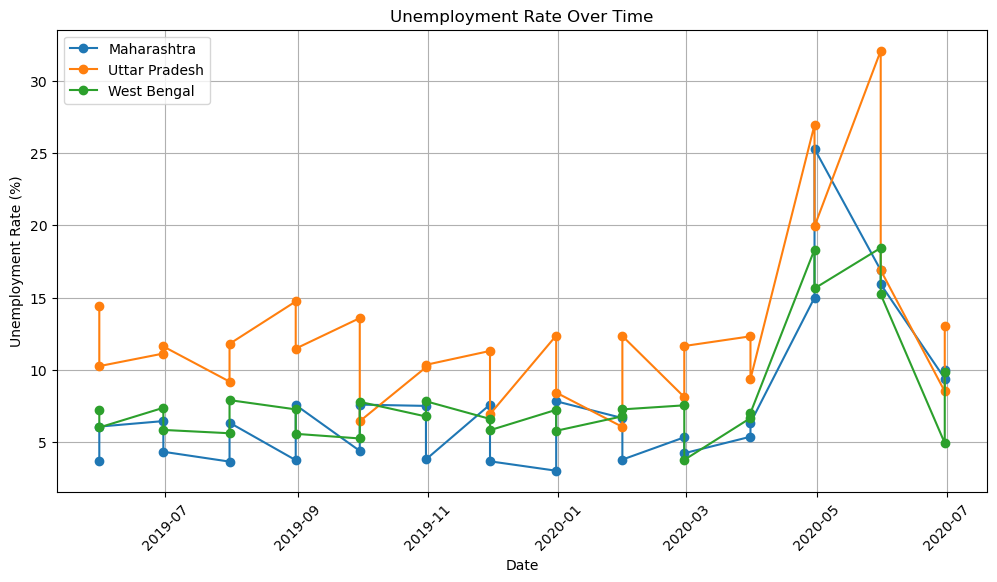

In [72]:
plt.figure(figsize=(12, 6))

for state in states:
    state_data = data[data['Region'] == state]
    plt.plot(
        state_data['Date'],
        state_data['Estimated Unemployment Rate (%)'],
        marker='o',
        label=state)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Top 10 states with highest average unemployment rate

In [73]:
 state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

In [74]:
top10 = state_avg.sort_values(ascending=False).head(10)

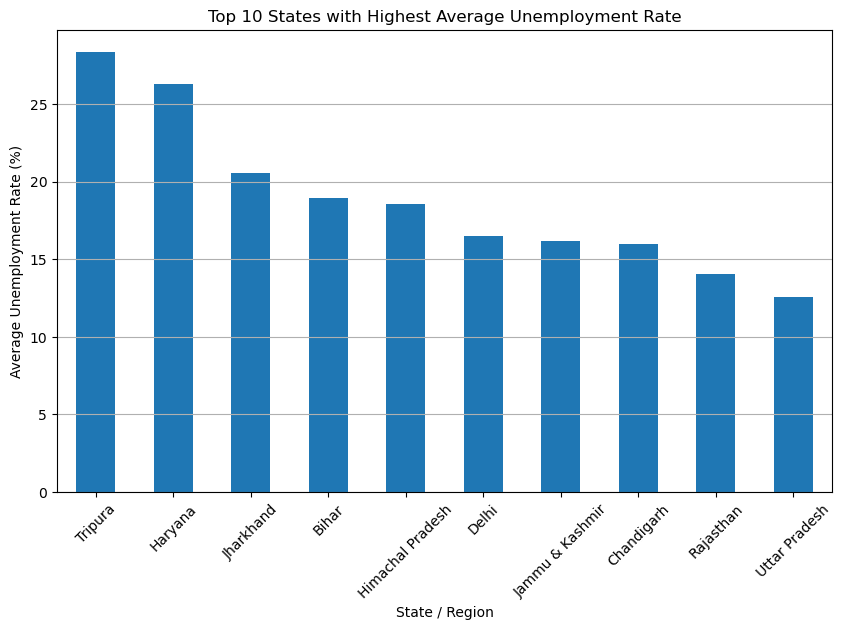

In [75]:
plt.figure(figsize=(10, 6))
top10.plot(kind='bar')

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("State / Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

### Interpretation
The bar chart shows the 10 states/regions having the highest average unemployment rate. 

The state at the top of the chart has the highest average unemployment rate among the selected states.

Higher unemployment rates indicate lower employment opportunities in those regions.

The differences between the bars show that unemployment is not equal across all regions.

States with higher unemployment may require more employment opportunities and job-creation programs.

This analysis helps identify the regions that may need greater attention for employment planning

In [ ]:
### 

In [77]:
data = df[['Estimated Unemployment Rate (%)',
           'Estimated Employed',
           'Estimated Labour Participation Rate (%)']]

In [78]:
correlation = data.corr()

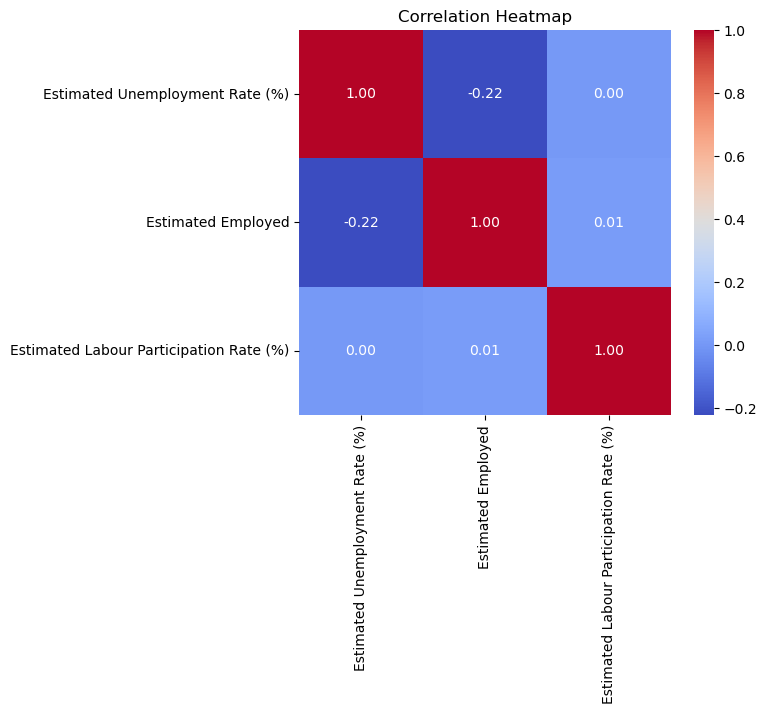

In [88]:
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

### Interpretation 
+1 → Strong positive correlation

-1 → Strong negative correlation

0 → Little or no correlation

The heatmap helps understand the relationship between unemployment rate, employment, and labour participation rate.

### # Pre-Covid vs post-Covid comparison (split data by data , calculate mean rates for each period)

In [82]:
pre_covid = df[df['Date'] < '2020-03-01']
post_covid = df[df['Date'] >= '2020-03-01']

In [83]:
pre_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_mean = post_covid['Estimated Unemployment Rate (%)'].mean()

In [84]:
print("Pre-COVID Average Unemployment Rate:", pre_mean)
print("Post-COVID Average Unemployment Rate:", post_mean)

Pre-COVID Average Unemployment Rate: 9.622646252635613
Post-COVID Average Unemployment Rate: 17.774362745098035


## Compare the two average rates.
Higher Post-COVID average → unemployment increased after COVID-19.

Lower Post-COVID average → unemployment decreased after COVID-19.

This helps understand the impact of COVID-19 on unemployment.